In [160]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, uniform, norm

# Exercise 1


## 1 

In [161]:
def linear_conguence_operator(a,c,M,x):
    xi =(a*x+c) % M
    random_number = xi/M
    return random_number,xi

In [162]:
def linear_congruence_RNG(a,c,M,x,n): 
    numbers = []
    for i in range(n): 
        random_number, x = linear_conguence_operator(a,c,M,x)
        numbers.append(random_number)
    return numbers

In [163]:
def chi_square_test(n_observed, n_expected,m):
    n_observed = np.asarray(n_observed, dtype=float)
    n_expected = np.asarray(n_expected, dtype=float)
    n = len(n_observed)
    df = n-1-m
    T = np.sum(((n_observed-n_expected)**2)/n_expected)
    return chi2.sf(T,df)


### a)

(array([1250.,  625., 1250.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([0.     , 0.09375, 0.1875 , 0.28125, 0.375  , 0.46875, 0.5625 ,
        0.65625, 0.75   , 0.84375, 0.9375 ]),
 <BarContainer object of 10 artists>)

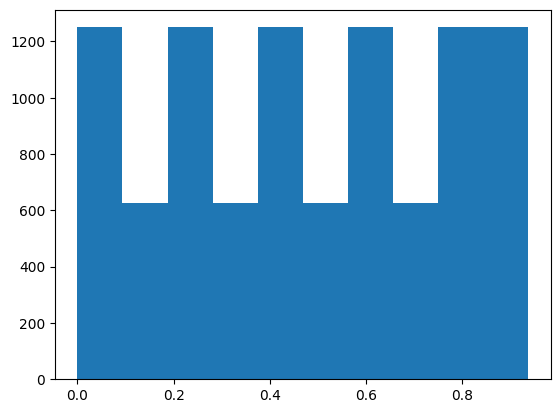

In [164]:
# Generating random numbers (10000) and histogram
num = linear_congruence_RNG(5,1,16,3,10000)
plt.hist(num,10)

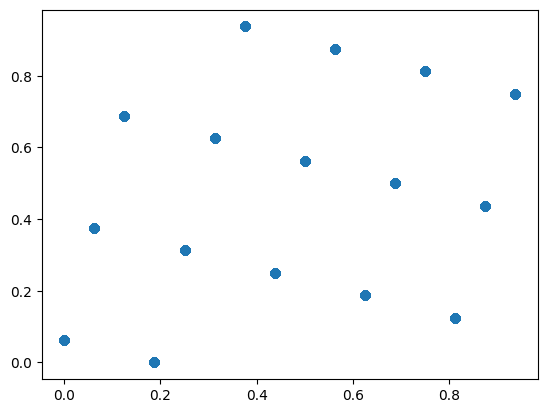

In [165]:
plt.scatter(num[:-1],num[1:])

In [166]:
# chi squared
bins = 10
observed, _ = np.histogram(num, bins=bins)
expected = np.ones(bins) * (10000 / bins)
chi_square_test(observed,expected, 0)

5.132863848608182e-196

In [167]:
# Kologmigigi
def empirical_cdf(x,num): 
    num = np.array(num)
    return np.sum(num <= x)/len(num)

def Kolmogorov_smirnov(num, n):
    x = np.linspace(0,1,n) # n controls how close we are to treating it like a continous function
    val = []
    for i in x:
        val.append(abs(uniform.cdf(i)-empirical_cdf(i,num)))

    return np.max( val)


In [168]:
# Need to standardize to compare
(np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(num, 100)

6.25756875

In [169]:
## Wald-Wolfowitz
def Wald_wolf(num):
    median = np.median(num)
    n1 = int(np.sum(np.array(num)>= median))
    n2 = int(np.sum(np.array(num) < median))
    mu = 2*(n1*n2/(n1+n2))+1
    sd = 2*(n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1)))

    label = ["A" if i >= median else "B" for i in num]
    T = 1
    for i in range(1, len(label)):
        if label[i] != label[i - 1]:
            T += 1
    
    T_std = abs((T-mu)/np.sqrt(sd))
    return 2*(norm.sf(T_std))


In [170]:
Wald_wolf(num)

5.924971670843113e-138

In [178]:
# Run test 2 - UP/down KNUTH

def Knuth_up_down(num):
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ]).flatten()

    runs = []
    current_len = 1

    for i in range(1, len(num)):
        if num[i] > num[i - 1]:
            current_len += 1
        else:
            runs.append(current_len)
            current_len = 1

    R = [0] * 6 
    for r in runs:
        if r >= 6:
            R[5] += 1
        else:
            R[r - 1] += 1
    R = np.array(R)
    z = 1/(len(num)-6)*((R-len(num)*B).T)@A@(R-len(num)*B)
    return chi2.sf(z,6)


In [179]:
def correlation_coef(num,h):
    n= len(num)
    num = np.array(num)
    c = 1/(n-h)*np.sum(num[:-h]*num[h:])
    c_std = abs((c-0.25)/np.sqrt(7/(144*n)))
    return 2*(norm.sf(c_std))


In [180]:
correlation_coef(num,4) # Det er endnu mere rejectable når h bliver større

0.032333865953261674

## Nu med gode tal

(array([ 985.,  902.,  977., 1060., 1017., 1029., 1027.,  949., 1012.,
        1042.]),
 array([7.55286310e-05, 1.00057015e-01, 2.00038501e-01, 3.00019986e-01,
        4.00001472e-01, 4.99982958e-01, 5.99964444e-01, 6.99945930e-01,
        7.99927416e-01, 8.99908902e-01, 9.99890388e-01]),
 <BarContainer object of 10 artists>)

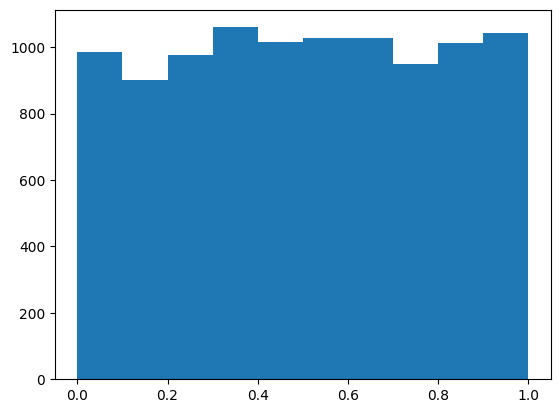

In [181]:
a = 1203515245
c =12345
M = 2**32
# Generating random numbers (10000) and histogram
num = linear_congruence_RNG(a,c,M,3,10000)
plt.hist(num,10)

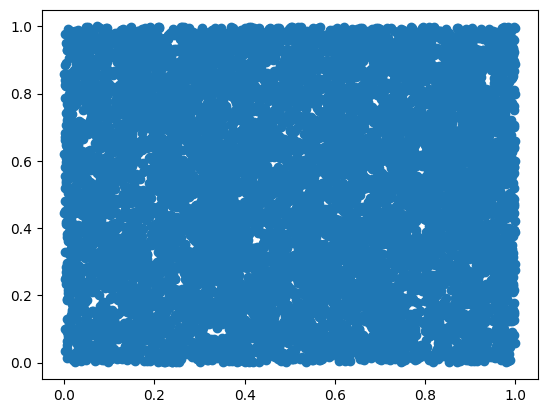

In [182]:
plt.scatter(num[:-1],num[1:])

In [183]:
# Test
ran = np.random.rand(10000)

bins = 10
observed, _ = np.histogram(ran, bins=bins)

expected = np.ones(bins) * len(ran) / bins

print("Chi_square", chi_square_test(observed, expected, 0))
print("Kolmogorov_smirnov", (np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(num, 100))
print("Wald", Wald_wolf(num))
print("Knut", Knuth_up_down(num))
print("corr, h=1", correlation_coef(num,1))


Chi_square 0.142142928974472
Kolmogorov_smirnov 1.5445955154545516
Wald 0.3680962993145487
Knut 0.4927805129254733
corr, h=1 0.008240736781768804


## 2

In [184]:
ran = np.random.rand(10000)

bins = 10
observed, _ = np.histogram(ran, bins=bins)

expected = np.ones(bins) * len(ran) / bins

print("Chi_square", chi_square_test(observed, expected, 0))
print("Kolmogorov_smirnov", (np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(ran, 100))
print("Wald", Wald_wolf(ran))
print("Knut", Knuth_up_down(ran))
print("corr, h=1", correlation_coef(ran,1))

Chi_square 0.25247889699836656
Kolmogorov_smirnov 0.7448403045454574
Wald 0.5618950581019283
Knut 0.3750249086205906
corr, h=1 0.6976114054808097
